In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

# Create directories
Path("../data/raw/property_data").mkdir(parents=True, exist_ok=True)
Path("../data/processed/property_data").mkdir(parents=True, exist_ok=True)

In [2]:
# Create sample property data for Atlanta ZIP codes
np.random.seed(42)

zip_codes = [30305, 30306, 30307, 30308, 30309]
n_properties = 500

sample_data = {
    'property_id': range(1, n_properties + 1),
    'zip_code': np.random.choice(zip_codes, n_properties),
    'bedrooms': np.random.randint(1, 6, n_properties),
    'bathrooms': np.random.randint(1, 4, n_properties) + np.random.choice([0, 0.5], n_properties),
    'sqft': np.random.randint(800, 4000, n_properties),
    'lot_size': np.random.randint(2000, 10000, n_properties),
    'year_built': np.random.randint(1950, 2024, n_properties),
    'garage': np.random.randint(0, 3, n_properties),
    'sale_price': np.random.randint(200000, 800000, n_properties),
    'sale_date': pd.date_range('2020-01-01', periods=n_properties, freq='D')
}

df_properties = pd.DataFrame(sample_data)
print(f"Created sample dataset with {len(df_properties)} properties")
df_properties.head(10)

Created sample dataset with 500 properties


,property_id,zip_code,bedrooms,bathrooms,sqft,lot_size,year_built,garage,sale_price,sale_date
0,1,30308,4,1.0,2868,8965,2009,2,716835,2020-01-01
1,2,30309,1,1.0,3758,7408,1968,2,423461,2020-01-02
2,3,30307,5,3.5,3714,6259,1998,0,638080,2020-01-03
3,4,30309,3,2.5,1593,2094,2012,2,613523,2020-01-04
4,5,30309,3,1.0,2947,7901,1971,0,564662,2020-01-05
5,6,30306,1,3.5,3599,8976,1973,2,481755,2020-01-06
6,7,30307,4,2.0,1277,3133,1979,1,538384,2020-01-07
7,8,30307,4,1.0,2422,8479,2007,0,439719,2020-01-08
8,9,30307,5,2.5,1739,6917,1980,0,466010,2020-01-09
9,10,30309,1,3.0,1325,2237,2013,1,637940,2020-01-10


In [3]:
# Basic Data Exploration
print("Dataset shape:", df_properties.shape)
print("\nData types:")
print(df_properties.dtypes)
print("\nMissing values:")
print(df_properties.isnull().sum())
print("\nBasic statistics:")
df_properties.describe()

Dataset shape: (500, 10)

Data types:
property_id             int64
zip_code                int64
bedrooms                int32
bathrooms             float64
sqft                    int32
lot_size                int32
year_built              int32
garage                  int32
sale_price              int32
sale_date      datetime64[ns]
dtype: object

Missing values:
property_id    0
zip_code       0
bedrooms       0
bathrooms      0
sqft           0
lot_size       0
year_built     0
garage         0
sale_price     0
sale_date      0
dtype: int64

Basic statistics:


,property_id,zip_code,bedrooms,bathrooms,sqft,lot_size,year_built,garage,sale_price,sale_date
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500
mean,250.500000,30306.970000,3.038000,2.247000,2439.302000,6088.358000,1986.930000,0.992000,498118.238000,2020-09-06 12:00:00
min,1.000000,30305.000000,1.000000,1.000000,801.000000,2016.000000,1950.000000,0.000000,203696.000000,2020-01-01 00:00:00
25%,125.750000,30306.000000,2.000000,1.500000,1682.750000,4159.750000,1968.750000,0.000000,347031.750000,2020-05-04 18:00:00
50%,250.500000,30307.000000,3.000000,2.500000,2441.500000,6082.500000,1988.000000,1.000000,502339.000000,2020-09-06 12:00:00
75%,375.250000,30308.000000,4.000000,3.000000,3293.750000,8213.500000,2005.250000,2.000000,625603.250000,2021-01-09 06:00:00
max,500.000000,30309.000000,5.000000,3.500000,3992.000000,9993.000000,2023.000000,2.000000,798506.000000,2021-05-14 00:00:00
std,144.481833,1.425891,1.441079,0.857299,942.298509,2340.062058,21.144438,0.835063,165358.711465,NaN


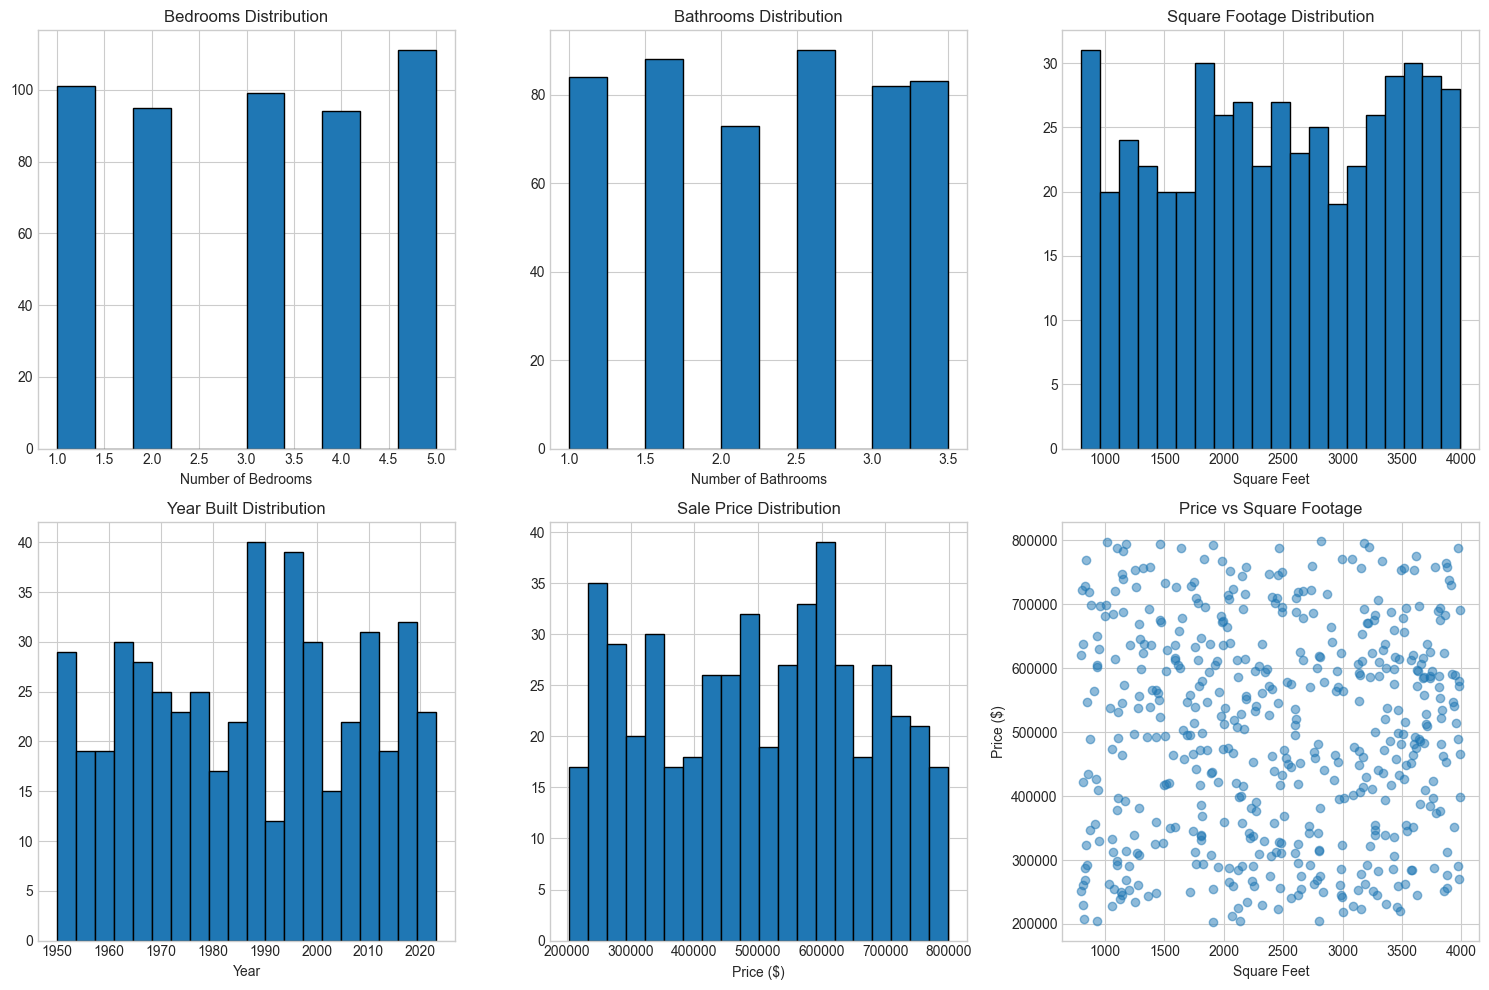

In [4]:
# Distribution of Key Features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(df_properties['bedrooms'], bins=10, edgecolor='black')
axes[0, 0].set_title('Bedrooms Distribution')
axes[0, 0].set_xlabel('Number of Bedrooms')

axes[0, 1].hist(df_properties['bathrooms'], bins=10, edgecolor='black')
axes[0, 1].set_title('Bathrooms Distribution')
axes[0, 1].set_xlabel('Number of Bathrooms')

axes[0, 2].hist(df_properties['sqft'], bins=20, edgecolor='black')
axes[0, 2].set_title('Square Footage Distribution')
axes[0, 2].set_xlabel('Square Feet')

axes[1, 0].hist(df_properties['year_built'], bins=20, edgecolor='black')
axes[1, 0].set_title('Year Built Distribution')
axes[1, 0].set_xlabel('Year')

axes[1, 1].hist(df_properties['sale_price'], bins=20, edgecolor='black')
axes[1, 1].set_title('Sale Price Distribution')
axes[1, 1].set_xlabel('Price ($)')

axes[1, 2].scatter(df_properties['sqft'], df_properties['sale_price'], alpha=0.5)
axes[1, 2].set_title('Price vs Square Footage')
axes[1, 2].set_xlabel('Square Feet')
axes[1, 2].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

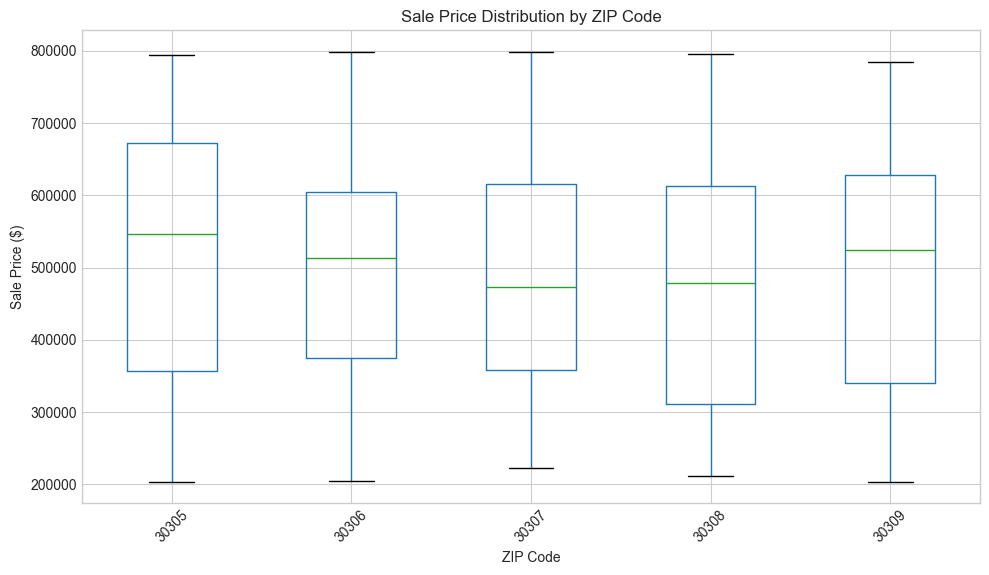

In [5]:
# Price by ZIP Code
plt.figure(figsize=(10, 6))
df_properties.boxplot(column='sale_price', by='zip_code', ax=plt.gca())
plt.title('Sale Price Distribution by ZIP Code')
plt.suptitle('')  # Remove default title
plt.xlabel('ZIP Code')
plt.ylabel('Sale Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

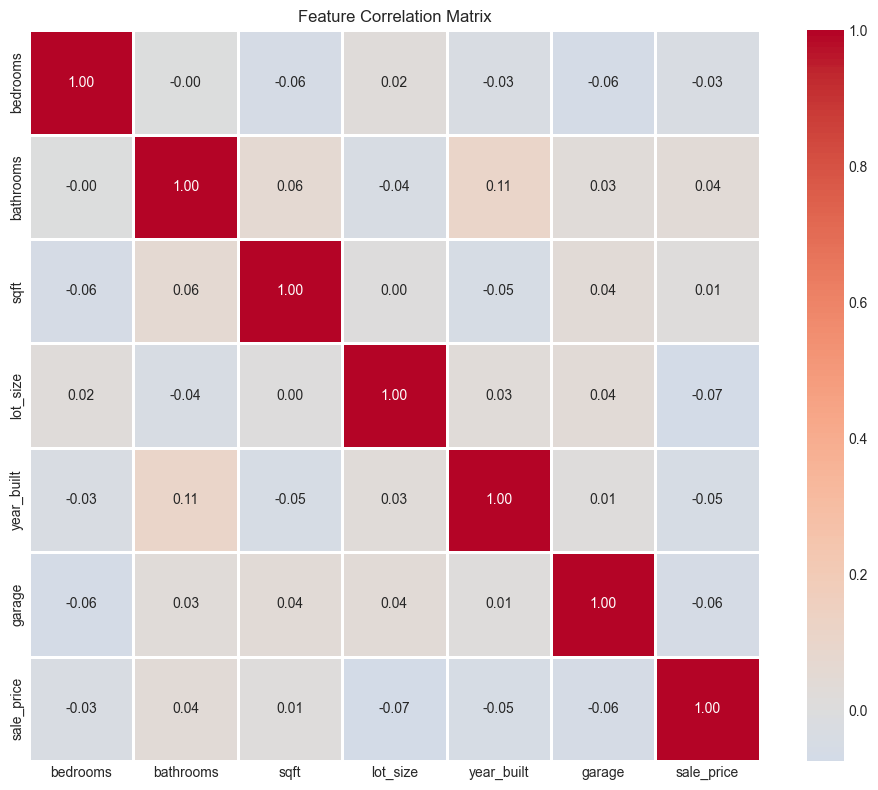

In [6]:
# Correlation Analysis
# Select numeric columns only
numeric_cols = ['bedrooms', 'bathrooms', 'sqft', 'lot_size', 'year_built', 'garage', 'sale_price']
correlation_matrix = df_properties[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [7]:
# Save Processed Property Data
df_properties.to_csv("../data/processed/property_data/atlanta_properties.csv", index=False)
print("Property data saved to ../data/processed/property_data/atlanta_properties.csv")
print(f"  Total properties: {len(df_properties)}")
print(f"  Date range: {df_properties['sale_date'].min()} to {df_properties['sale_date'].max()}")

Property data saved to ../data/processed/property_data/atlanta_properties.csv
  Total properties: 500
  Date range: 2020-01-01 00:00:00 to 2021-05-14 00:00:00
